In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from pyro_cases.utils.vae_dict import vae_dict
from pyro_cases.utils.run_amortized_favi import train_and_test_amortized_favi

In [3]:
device = torch.device("cuda:4")

In [4]:
out_dict = train_and_test_amortized_favi(task_name="arm_roaches_overdispersion",
                                        seed=123456,
                                        device=device,
                                        lr=1e-3,
                                        lr_schedule="cosine_annealing",
                                        batch_size=1024,
                                        network_width=32,
                                        steps=1000,
                                        test_seed=7272,
                                        num_test_obs=1000,
                                        show_progress=True,
                                        return_vae=True,
                                        suppress_error=False,
                                        nn_type="deep_set")

100%|██████████| 1000/1000 [00:12<00:00, 80.75it/s]


[task arm_roaches_overdispersion seed 123456 completes] task start time: Sun Jul 27 12:08:39 2025; task end time: Sun Jul 27 12:08:51 2025; cost time: 12.4 seconds


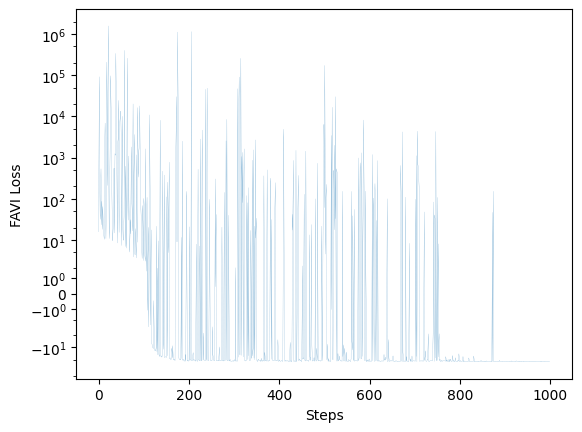

In [5]:
plt.plot(out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
plt.yscale("asinh")
plt.show()

### VSBC

In [6]:
favi_vsbc = out_dict["favi_vsbc"]

In [7]:
def plot_vsbc(vsbc_matrix: torch.Tensor):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.tight_layout()
    fig.show()

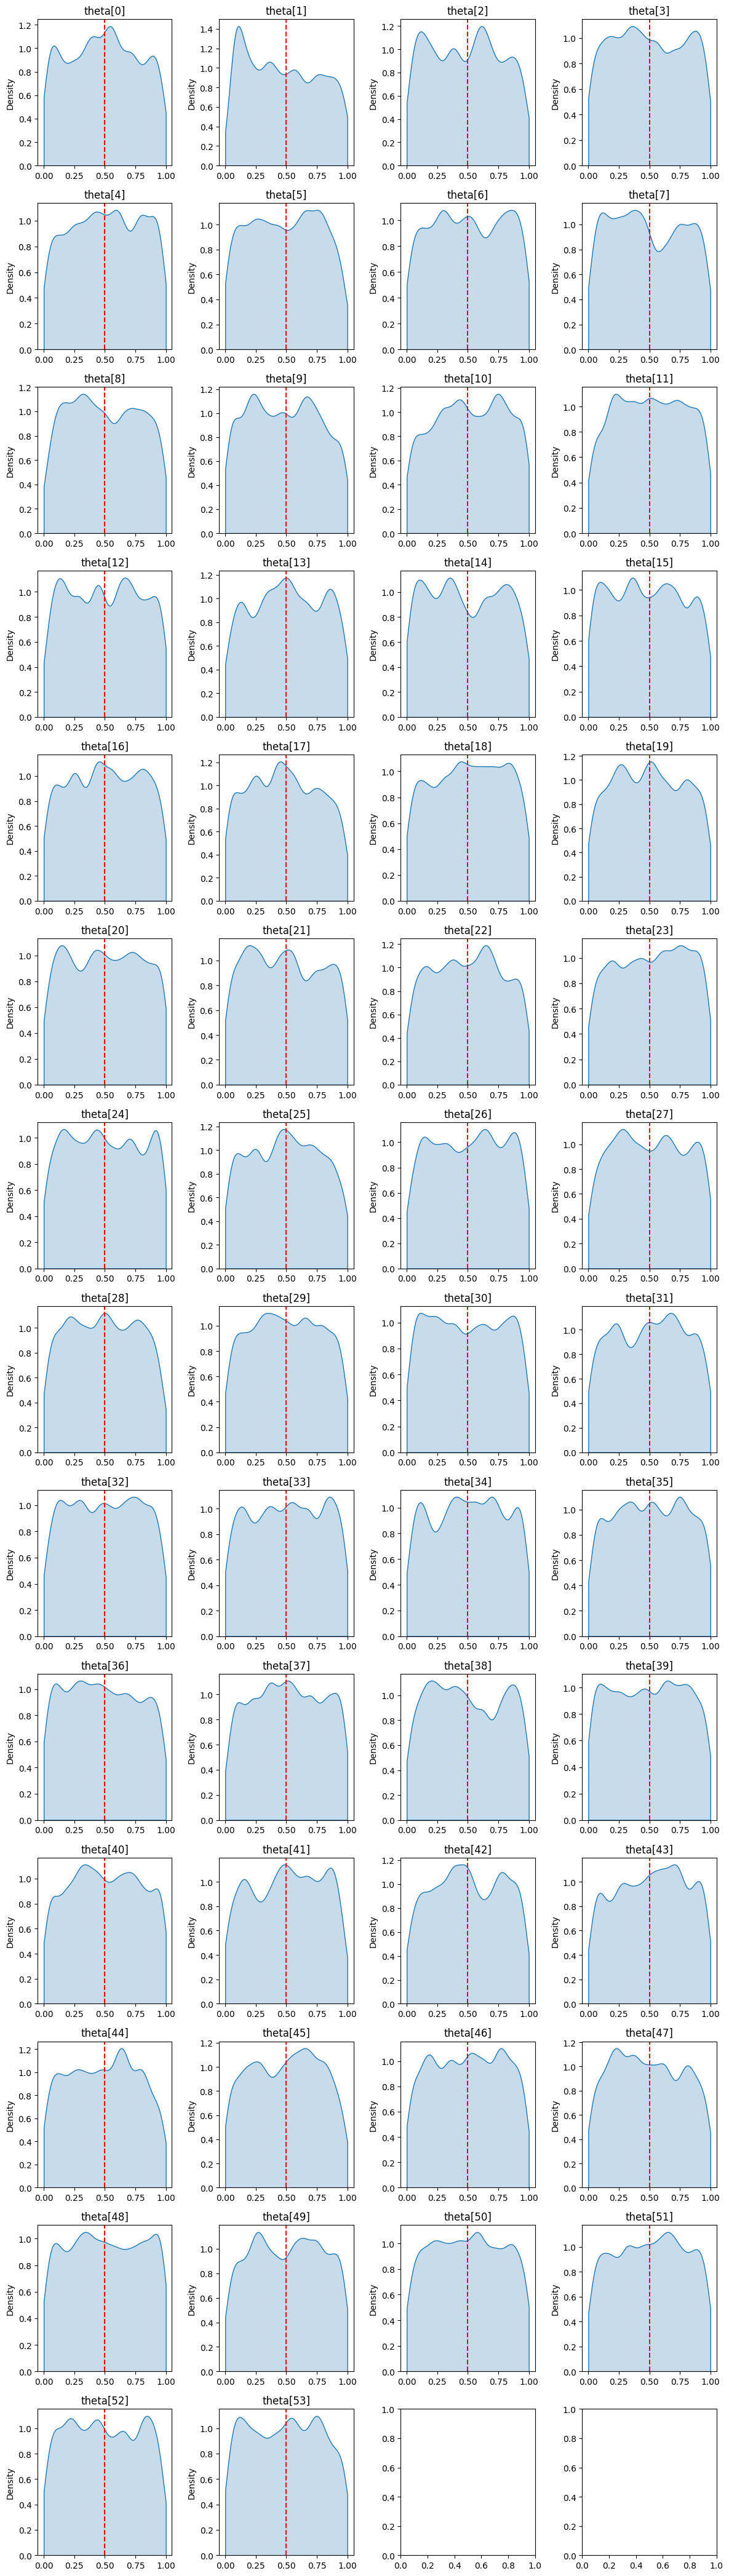

In [8]:
plot_vsbc(favi_vsbc)

### Output

In [9]:
out_dict.keys()

dict_keys(['seed', 'task', 'favi_training_loss', 'favi_test_sample_dict', 'favi_test_result_dict', 'favi_vae_wrap', 'favi_vsbc', 'favi_error'])

In [10]:
out_dict["favi_test_result_dict"].keys()

dict_keys(['obs_seed', 'obs', 'est_theta1', 'est_theta2', 'raw_pred', 'true_theta'])

In [11]:
out_dict["favi_test_result_dict"]["obs"].shape

torch.Size([1000, 50, 5])

In [12]:
out_dict["favi_test_result_dict"]["true_theta"].shape

torch.Size([1000, 54])

In [13]:
out_dict["favi_test_result_dict"]["est_theta1"][:5]

tensor([[-1.2936e-03, -1.9864e-02, -1.5289e-03, -1.3354e-03,  9.6818e-04,
          2.4561e-04,  1.2177e-04,  5.8135e-05, -5.3931e-04, -7.2787e-04,
         -3.4713e-04,  1.9529e-04,  9.3643e-04,  5.3131e-04,  2.0336e-05,
          1.8176e-04, -6.9160e-05, -7.8493e-04,  3.8971e-04,  4.7797e-04,
         -7.1193e-05, -2.2895e-04, -1.0242e-04,  2.5426e-04, -4.3519e-04,
          5.8338e-04,  1.6970e-03,  4.9146e-04, -3.2825e-05,  7.7749e-04,
          7.8070e-05,  3.0084e-04, -4.1267e-04,  1.1593e-04, -4.0102e-05,
         -2.3571e-04,  4.9463e-04,  2.7894e-04,  7.1115e-04, -1.5422e-03,
          1.1081e-04, -2.2866e-05,  4.8893e-04, -1.1551e-04, -2.3077e-04,
         -1.8055e-04, -4.3238e-04, -4.4753e-04,  2.9710e-04,  1.7283e-04,
         -5.8112e-04,  2.1691e-04, -4.4014e-05,  1.7142e-04],
        [-6.1235e-04, -1.5723e-02,  1.1935e-03,  1.0418e-03,  8.2493e-04,
         -3.5618e-04, -3.5631e-04,  1.3432e-04, -5.3577e-05, -7.1828e-04,
         -9.4911e-04, -2.0617e-04,  8.2254e-04,  3

In [14]:
out_dict["favi_test_result_dict"]["est_theta2"][:5]

tensor([[0.0401, 0.0309, 0.0398, 0.0392, 0.0098, 0.0099, 0.0099, 0.0098, 0.0099,
         0.0099, 0.0098, 0.0098, 0.0098, 0.0098, 0.0099, 0.0098, 0.0098, 0.0098,
         0.0098, 0.0098, 0.0099, 0.0098, 0.0098, 0.0099, 0.0098, 0.0098, 0.0098,
         0.0098, 0.0098, 0.0099, 0.0099, 0.0099, 0.0098, 0.0099, 0.0099, 0.0098,
         0.0099, 0.0098, 0.0098, 0.0098, 0.0098, 0.0099, 0.0098, 0.0099, 0.0098,
         0.0099, 0.0098, 0.0099, 0.0098, 0.0098, 0.0098, 0.0099, 0.0098, 0.0098],
        [0.0375, 0.0317, 0.0371, 0.0371, 0.0092, 0.0093, 0.0092, 0.0092, 0.0092,
         0.0093, 0.0092, 0.0092, 0.0092, 0.0092, 0.0093, 0.0092, 0.0092, 0.0092,
         0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092,
         0.0092, 0.0092, 0.0092, 0.0093, 0.0093, 0.0092, 0.0092, 0.0092, 0.0092,
         0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0093, 0.0092,
         0.0093, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0093, 0.0092, 0.0092],
        [0.0403, 0.0311, 0

### Smoke Test

In [15]:
for i, task_name in enumerate(vae_dict.keys()):
    print(f"[{i}] run task {task_name}")
    out_dict = train_and_test_amortized_favi(task_name=task_name,
                                            seed=123456,
                                            device=device,
                                            lr=1e-3,
                                            lr_schedule="cosine_annealing",
                                            batch_size=1024,
                                            network_width=32,
                                            steps=10,
                                            test_seed=7272,
                                            num_test_obs=1000,
                                            show_progress=False,
                                            silent=False,
                                            return_vae=True,
                                            suppress_error=False,
                                            nn_type="deep_set")
    print(f"[{i}] task {task_name} passes")
    print()

[0] run task gaussian_linear
[task gaussian_linear seed 123456 completes] task start time: Sun Jul 27 12:09:01 2025; task end time: Sun Jul 27 12:09:01 2025; cost time: 0.1 seconds
[0] task gaussian_linear passes

[1] run task gaussian_linear_uniform
[task gaussian_linear_uniform seed 123456 completes] task start time: Sun Jul 27 12:09:01 2025; task end time: Sun Jul 27 12:09:01 2025; cost time: 0.1 seconds
[1] task gaussian_linear_uniform passes

[2] run task slcp
[task slcp seed 123456 completes] task start time: Sun Jul 27 12:09:01 2025; task end time: Sun Jul 27 12:09:01 2025; cost time: 0.1 seconds
[2] task slcp passes

[3] run task slcp_distractors
[task slcp_distractors seed 123456 completes] task start time: Sun Jul 27 12:09:01 2025; task end time: Sun Jul 27 12:09:01 2025; cost time: 0.1 seconds
[3] task slcp_distractors passes

[4] run task bernoulli_glm_raw
[task bernoulli_glm_raw seed 123456 completes] task start time: Sun Jul 27 12:09:01 2025; task end time: Sun Jul 27 12: